# **Hierarchical Clustering**

Hierarchical Clustering relies on measuring the similarity between data points, grouping those that are most alike. This method shares conceptual similarities with other clustering techniques, such as K-Means, in its reliance on distance metrics to define similarity.

## **Advantages of Hierarchical Clustering**

Hierarchical Clustering offers several benefits:

*   **Interpretability and Visualization**: The method is intuitive and easy to visualize, particularly with dendrograms.
*   **No Predefined Number of Clusters**: Unlike K-Means, it does not require specifying the number of clusters (K) beforehand. This allows users to determine an appropriate number of clusters by examining the hierarchy structure.

<br>

## **Approaches to Hierarchical Clustering**

There are two primary approaches:

1.  **Agglomerative (Bottom-Up)**: Each data point initially forms its own cluster. Clusters are then progressively merged based on their similarity until all points belong to a single, overarching cluster.


2.  **Divisive (Top-Down)**: All data points begin as a single cluster. This cluster is then recursively split into smaller clusters based on dissimilarity until each data point forms its own cluster.

<br>

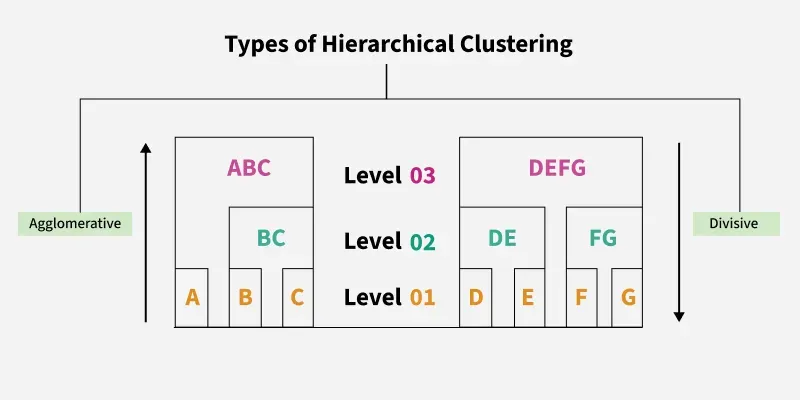

## **Agglomerative Clustering Process**

Agglomerative Clustering is the more commonly used approach. The process involves iteratively merging the most similar clusters:

1.  **Individual Clusters**: Start with each data point as a single cluster.
2.  **Calculate Similarity**: Compute the similarity (or distance) between all pairs of clusters.
3.  **Merge Closest Clusters**: Merge the two closest (most similar) clusters.
4.  **Repeat**: Recalculate similarities and repeat the merging process until only one cluster remains.

This process results in a hierarchy of clusters, which can be visualized as a **dendrogram**.

<br>

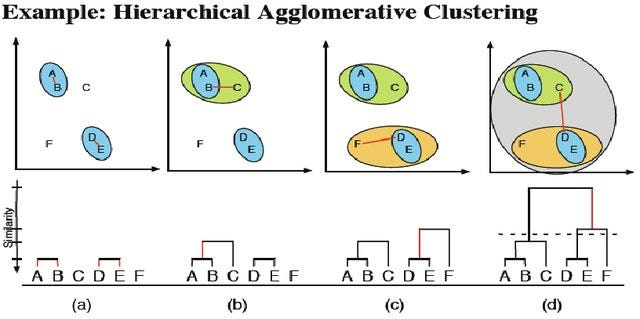

## **Similarity Metric**

Just like in K-Means, Hierarchical Clustering relies on a distance metric to quantify the similarity/dissimilarity between data points.

Many options:

*   Euclidean Distance
*   Manhattan
*   Cosine
* etc.


<br>

**Euclidean Distance**:

For two data points $\mathbf{x}_i = (x_{i1}, x_{i2}, ..., x_{ip})$ and $\mathbf{x}_j = (x_{j1}, x_{j2}, ..., x_{jp})$ in a $p$-dimensional feature space, the Euclidean distance is given by:

$$d(\mathbf{x}_i, \mathbf{x}_j) = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

Each dimension (from 1 to $p$) corresponds to a feature in our dataset.

<br>

Not only is it easy to understand,but it's also going to be very convenient for scaled data:

- When data features are scaled (e.g., using `MinMaxScaler` or `StandardScaler`), Euclidean distance becomes more robust and interpretable across different feature scales.

- When data are scaled using `MinMaxScaler` the maximum distance between a feature would be one.

<br>

## **The Dendrogram**

A dendrogram is a tree-like diagram that records the sequences of merges or splits. It visually represents the hierarchy of clusters.

*   **X-axis**: Represents the individual data points or observations.
*   **Y-axis**: Represents the distance or dissimilarity between clusters. The height at which two clusters are joined indicates their distance.

<br>

**Interpreting Dendrograms**:

*   **Cluster Distance**: Shorter vertical lines connecting clusters indicate higher similarity between them.
*   **Determining K**: By drawing a horizontal line (a 'slice') across the dendrogram, one can decide the number of clusters. Each vertical line that the horizontal slice crosses represents a cluster. The ideal cut-off point is often identified where the longest vertical line that does not cross the horizontal line is observed, suggesting a natural grouping.

<br>

**Trade-off:**
- It's very computationally expensive to compute

and display for larger datasets

<br>

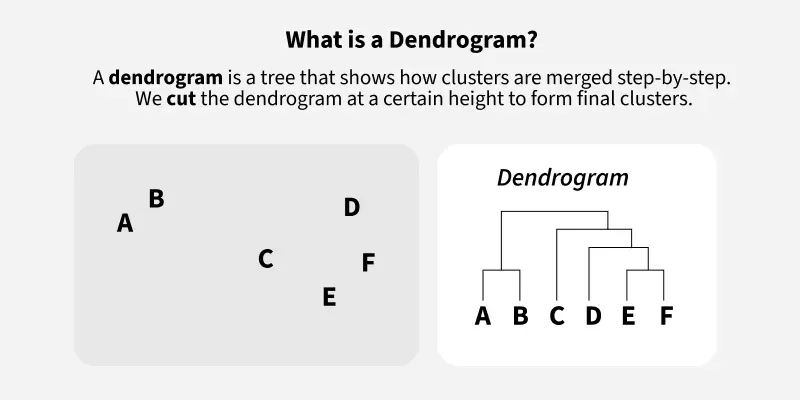

## **Linkage Criteria**

When merging clusters, a 'linkage criterion' defines how the distance between two clusters is measured. This is crucial as a cluster can contain multiple points.

Common linkage methods include:

*   **Ward's Linkage**: Minimizes the variance of the clusters being merged. This method is often preferred as it tends to produce spherical clusters of similar size.
*   **Average Linkage**: Uses the average distance between all data points in one cluster and all data points in another cluster.
*   **Complete (Maximum) Linkage**: Considers the maximum distance between any two data points in the two clusters being merged.
*   **Single (Minimum) Linkage**: Considers the minimum distance between any two data points in the two clusters being merged.

The choice of linkage method can significantly impact the resulting cluster structure.

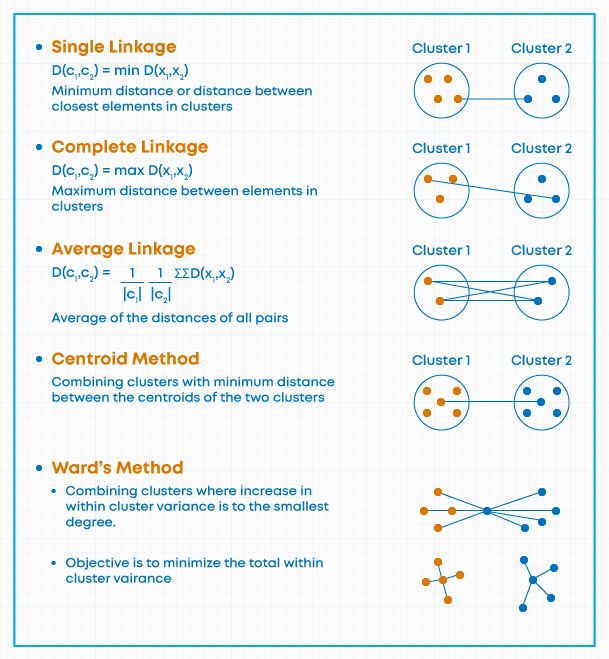

<br>

## **Hierarchical Clustering Implementation**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/cluster_mpg.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 27.7+ KB


In [ ]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:
df['origin'].value_counts()

,count
origin,
usa,245
japan,79
europe,68


In [ ]:
df_w_dummies = pd.get_dummies(df.drop('name',axis=1))

In [ ]:
df_w_dummies

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,False,False,True
388,44.0,4,97.0,52.0,2130,24.6,82,True,False,False
389,32.0,4,135.0,84.0,2295,11.6,82,False,False,True
390,28.0,4,120.0,79.0,2625,18.6,82,False,False,True


### **Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_w_dummies)
scaled_data

array([[0.2393617 , 1.        , 0.61757106, ..., 0.        , 0.        ,
        1.        ],
       [0.15957447, 1.        , 0.72868217, ..., 0.        , 0.        ,
        1.        ],
       [0.2393617 , 1.        , 0.64599483, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.61170213, 0.2       , 0.17312661, ..., 0.        , 0.        ,
        1.        ],
       [0.50531915, 0.2       , 0.13436693, ..., 0.        , 0.        ,
        1.        ],
       [0.58510638, 0.2       , 0.13178295, ..., 0.        , 0.        ,
        1.        ]])

In [ ]:
scaled_df = pd.DataFrame(scaled_data,columns=df_w_dummies.columns)

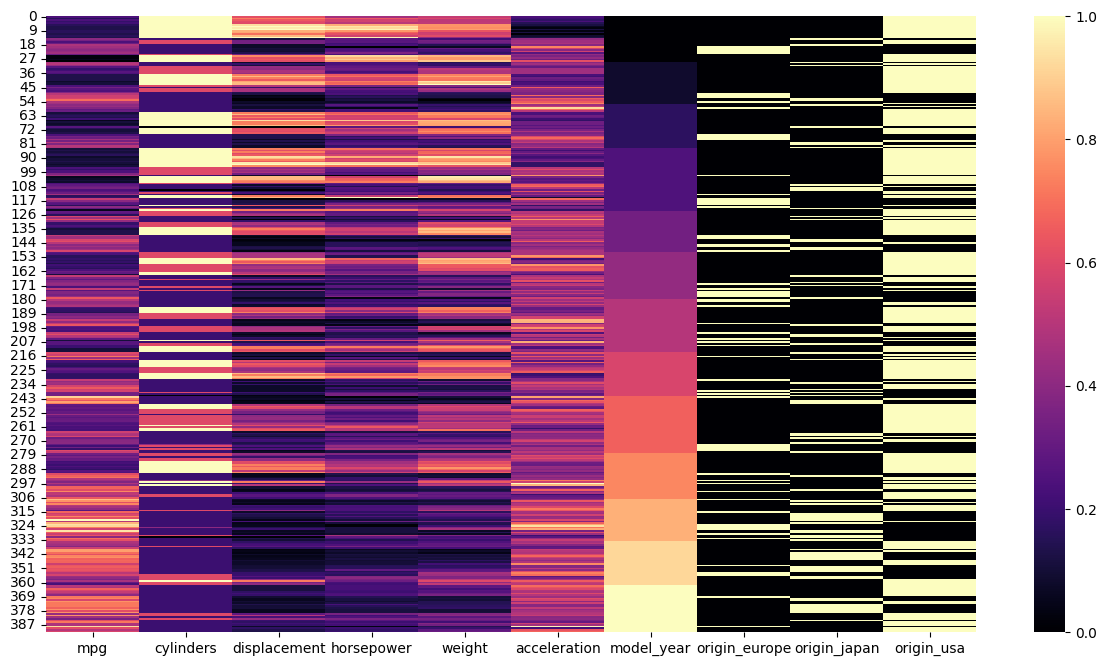

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(scaled_df,cmap='magma');

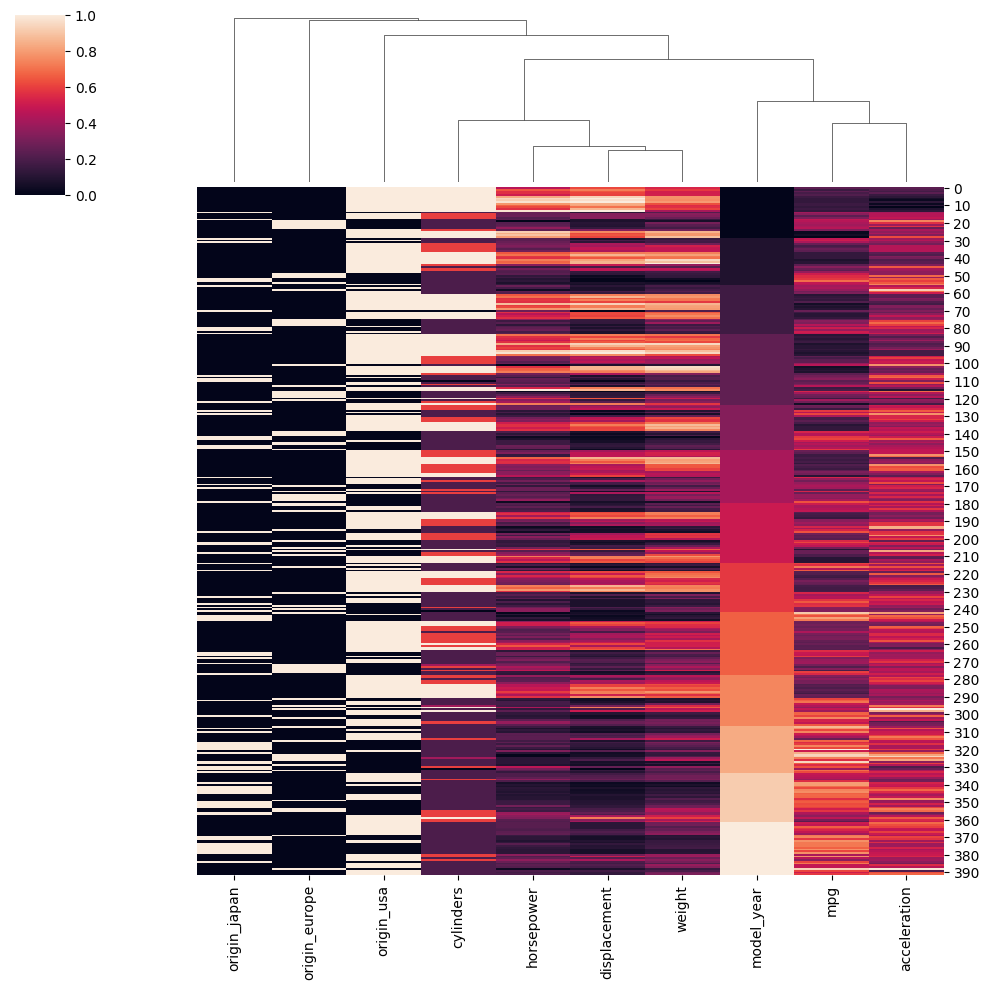

In [ ]:
sns.clustermap(scaled_df,row_cluster=False)

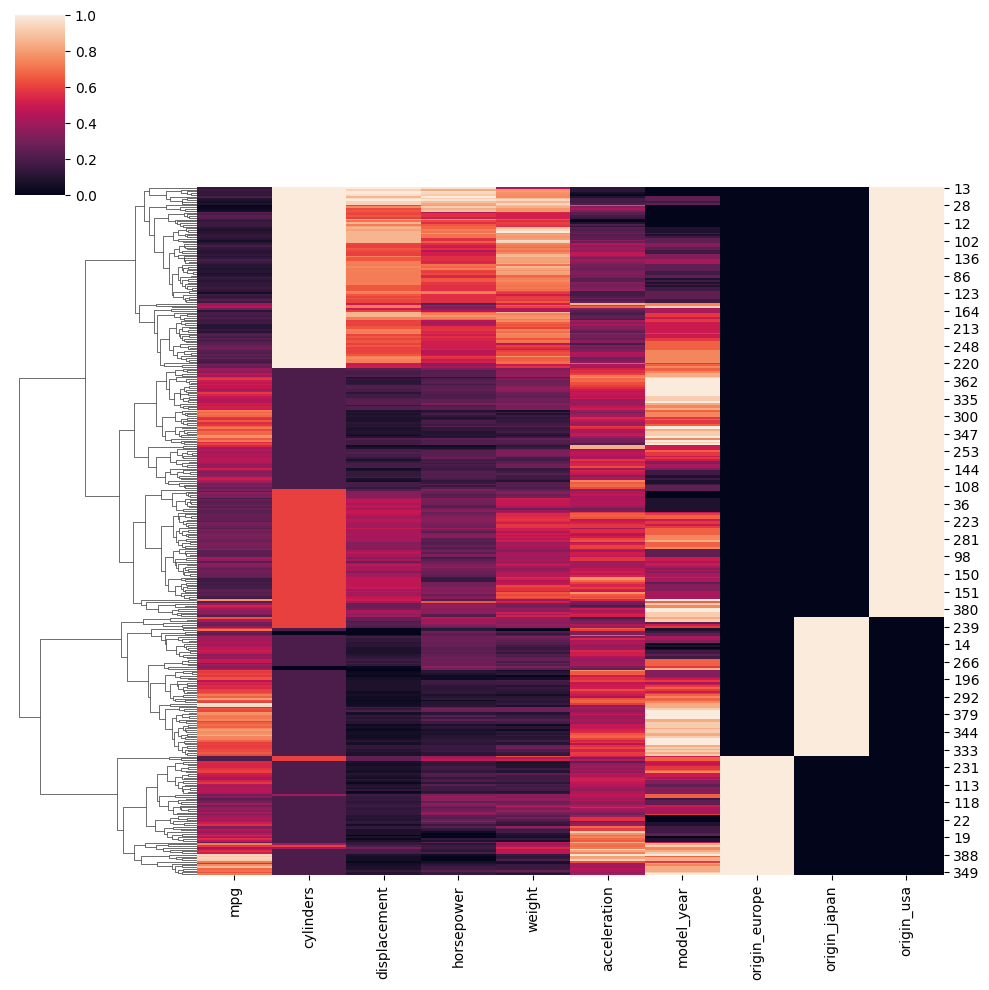

In [ ]:
sns.clustermap(scaled_df,col_cluster=False)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=4)

In [ ]:
cluster_labels = model.fit_predict(scaled_df)

In [ ]:
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 3, 2, 2, 2,
       2, 2, 0, 1, 1, 1, 1, 3, 0, 3, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 2, 0, 3, 0, 2, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 2, 2, 0, 3, 3, 0, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 3, 0, 3,
       3, 0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 3, 0, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 0, 2, 2, 3, 3, 2, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 3, 0, 0, 0, 3, 2, 3, 0, 2, 0, 2,
       2, 2, 2, 3, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 3, 0,
       0, 0, 0, 2, 3, 3, 0, 2, 1, 2, 3, 2, 1, 1, 1, 1, 3, 0, 2, 0, 3, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 3, 0, 0, 0, 3, 2, 3, 2, 3,
       2, 0, 3, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 3, 3, 0, 3, 0, 0, 3, 2, 2, 2, 2, 2, 3, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 3, 0, 0, 2, 1, 2, 1, 0, 0,

<Axes: xlabel='mpg', ylabel='weight'>

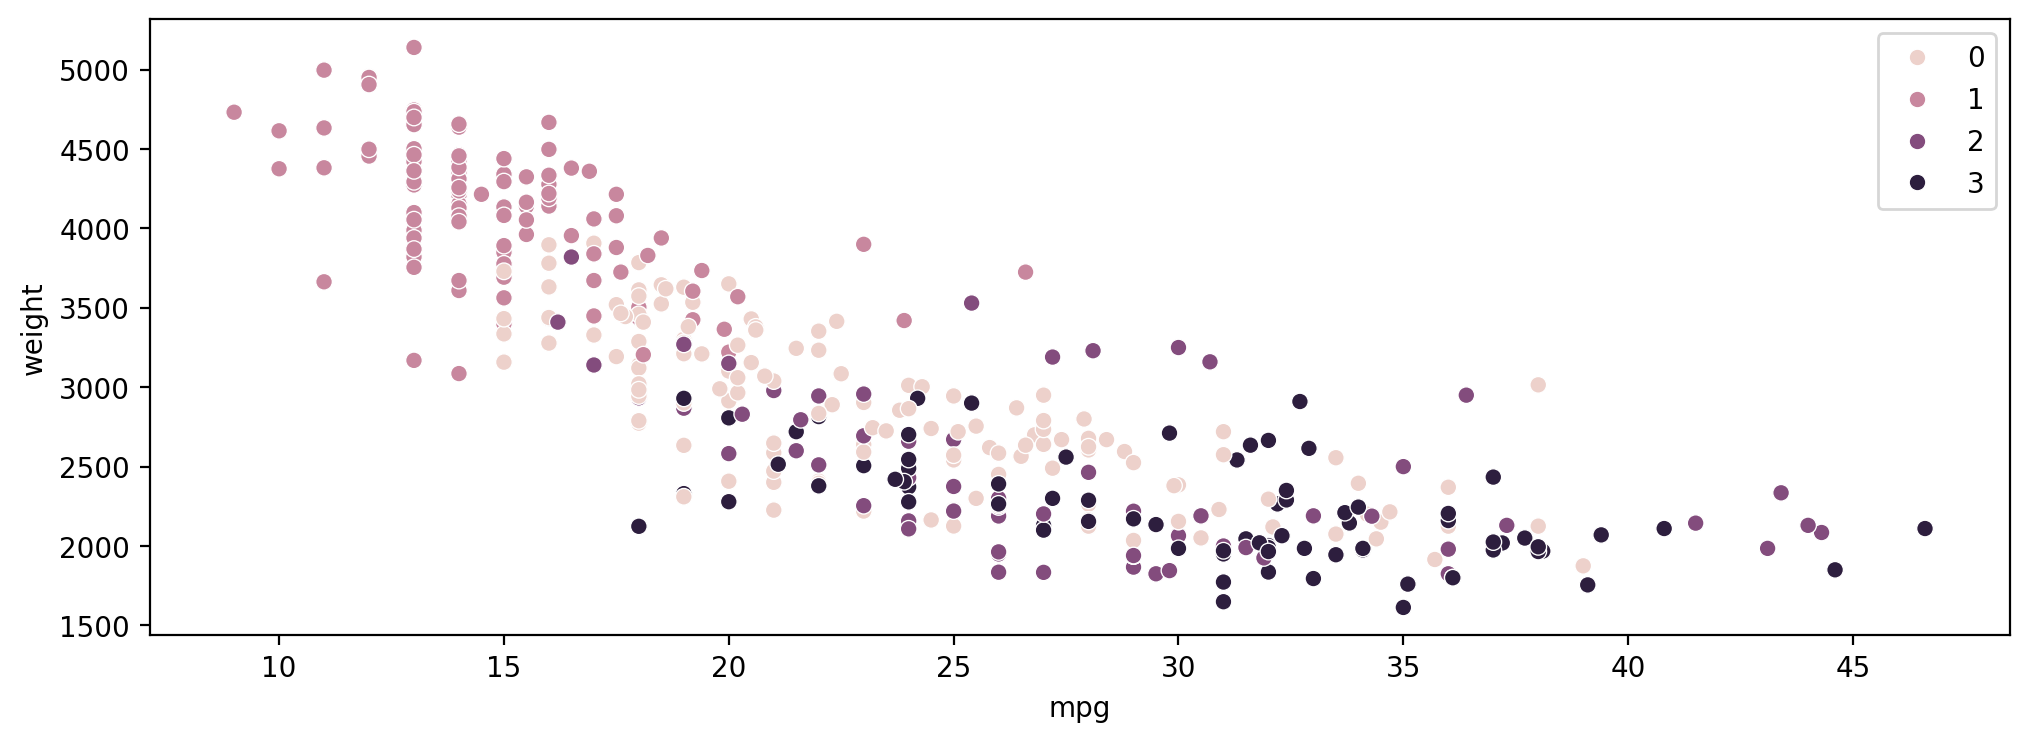

In [ ]:
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(data=df,x='mpg',y='weight',hue=cluster_labels)

### **Exploring Number of Clusters with Dendrograms**

Make sure to read the documentation online!
https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

#### Assuming every point starts as its own cluster

In [ ]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=0)

In [ ]:
cluster_labels = model.fit_predict(scaled_df)

In [ ]:
cluster_labels

array([247, 252, 360, 302, 326, 381, 384, 338, 300, 279, 217, 311, 377,
       281, 232, 334, 272, 375, 354, 333, 317, 345, 329, 289, 305, 383,
       290, 205, 355, 269, 202, 144, 245, 297, 386, 358, 199, 337, 330,
       339, 293, 352, 283, 196, 253, 168, 378, 331, 201, 268, 256, 361,
       250, 197, 246, 371, 324, 230, 203, 261, 380, 376, 308, 389, 332,
       306, 236, 391, 350, 274, 288, 313, 231, 298, 100, 295, 210, 248,
       187, 390, 373, 266, 307, 379, 212, 357, 191, 314, 208, 249, 343,
       294, 374, 322, 323, 362, 188, 296, 369, 286, 251, 229, 244, 285,
       349, 365, 259, 213, 276, 215, 222, 204, 359, 287, 166, 387, 291,
       220, 216, 260, 129, 367, 340, 346, 301, 342, 228, 388, 370, 218,
       255, 327, 347, 278, 271, 258, 282, 318, 273, 123, 172, 382, 363,
       356, 195, 280, 239, 364, 267, 351, 186, 257, 277, 299, 127, 366,
       234, 385, 192, 372, 292, 233, 270, 263, 133, 165, 161, 198,  97,
       315, 134, 207, 147, 175, 262, 348,  98, 214,  48, 353, 17

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

### **Linkage Model**

In [ ]:
linkage_matrix = hierarchy.linkage(model.children_)

In [ ]:
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]])

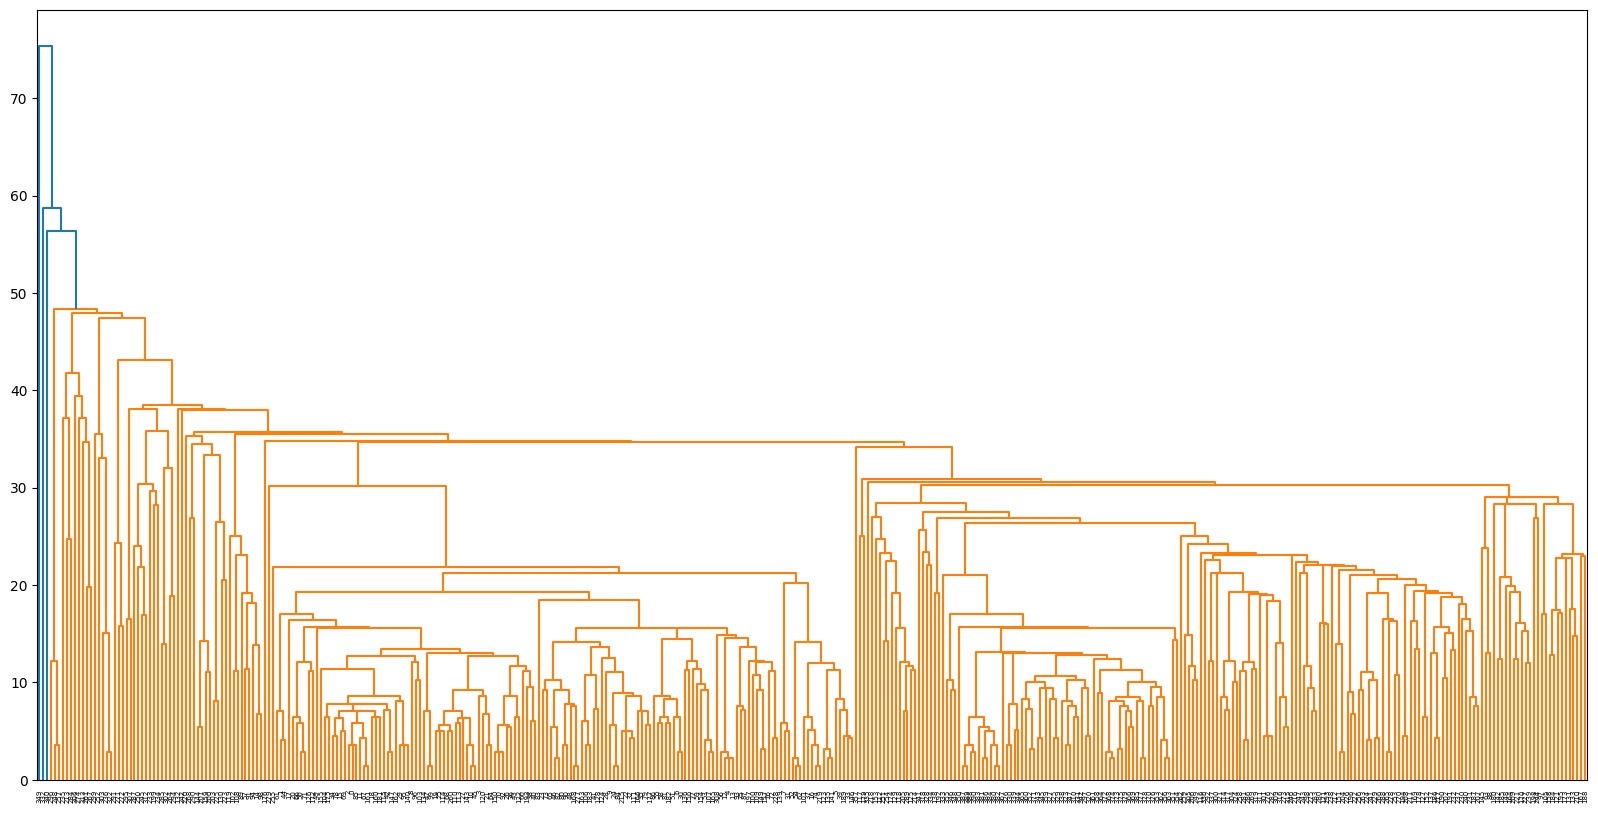

In [ ]:
plt.figure(figsize=(20,10))
# Warning! This plot will take awhile!!
dn = hierarchy.dendrogram(linkage_matrix)

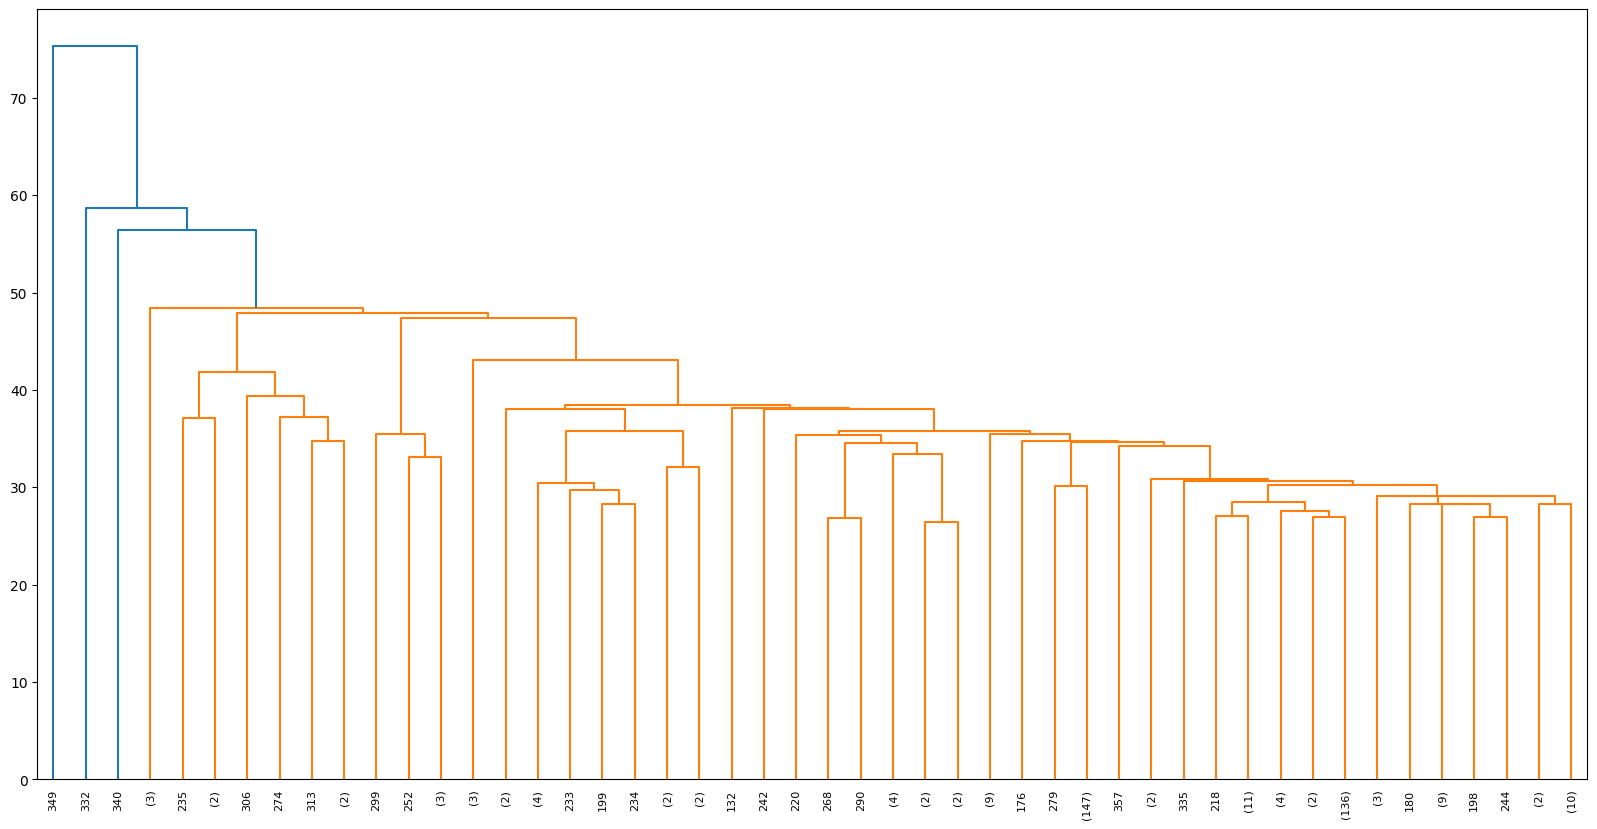

In [ ]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='lastp',p=48)

### **Choosing a Threshold Distance**

**What is the distance between two points?**

In [ ]:
scaled_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,0.384200,0.494388,0.326646,0.317768,0.386897,0.448888,0.498299,0.173469,0.201531,0.625000
std,0.207580,0.341157,0.270398,0.209191,0.240829,0.164218,0.306978,0.379136,0.401656,0.484742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.212766,0.200000,0.095607,0.157609,0.173589,0.343750,0.250000,0.000000,0.000000,0.000000
50%,0.365691,0.200000,0.214470,0.258152,0.337539,0.446429,0.500000,0.000000,0.000000,1.000000
75%,0.531915,1.000000,0.536822,0.434783,0.567550,0.537202,0.750000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
scaled_df['mpg'].idxmax()

320

In [ ]:
scaled_df['mpg'].idxmin()

28

In [ ]:
# https://stackoverflow.com/questions/1401712/how-can-the-euclidean-distance-be-calculated-with-numpy
a = scaled_df.iloc[320]
b = scaled_df.iloc[28]
dist = np.linalg.norm(a-b)

In [ ]:
dist

np.float64(2.3852929970374714)

#### **Max possible distance?**

Recall Euclidean distance: https://en.wikipedia.org/wiki/Euclidean_distance

In [ ]:
np.sqrt(len(scaled_df.columns))

np.float64(3.1622776601683795)

### **Creating a Model Based on Distance Threshold**

* distance_threshold
    * The linkage distance threshold above which, clusters will not be merged.

In [ ]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=2)

In [ ]:
cluster_labels = model.fit_predict(scaled_data)

In [ ]:
cluster_labels

array([ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  1,  4,  4,
        4,  1,  0,  0,  0,  0,  0,  4,  3,  3,  3,  3,  1,  7,  1,  4,  4,
        4,  4,  4,  3,  3,  3,  3,  3,  3,  3,  4,  7,  4,  4,  7,  0,  0,
        0,  1,  1,  0,  7,  1,  7,  0,  7,  7,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  1,  3,  3,  3,  3,  0,  0,  0,  0,  7,  1,  1,  7,  1,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  0,
        3,  3,  3,  3,  4,  1,  7,  1,  1,  7,  4,  0,  3,  3,  0,  0,  0,
        0,  3,  0, 10,  3,  4,  4,  4,  1,  7,  1,  7,  4,  4,  4,  3,  3,
        3,  3,  3,  0,  0,  0,  1,  1,  7,  0,  0,  1,  1,  0,  4,  4,  4,
        4,  5,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  1,  7,  4,  7,  1,
        0,  1,  4,  0,  4,  0,  0,  0,  0,  1,  0,  0,  7,  7,  0,  5,  5,
        5,  5,  4,  4,  4,  4,  7,  7,  0,  1,  9,  4,  9,  4,  0,  1,  1,
        7,  0,  5,  8, 10,  0,  5,  5,  5,  5,  1,  2,  8,  7,  1,  5,  5,
        5,  5,  9,  9,  9

In [ ]:
np.unique(cluster_labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

### **Linkage Matrix**

Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage

  A (n-1) by 4 matrix Z is returned. At the i-th iteration, clusters with indices Z[i, 0] and Z[i, 1] are combined to form cluster n + i. A cluster with an index less than n corresponds to one of the original observations. The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2]. The fourth value Z[i, 3] represents the number of original observations in the newly formed cluster.

In [ ]:
linkage_matrix = hierarchy.linkage(model.children_)

In [ ]:
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]])

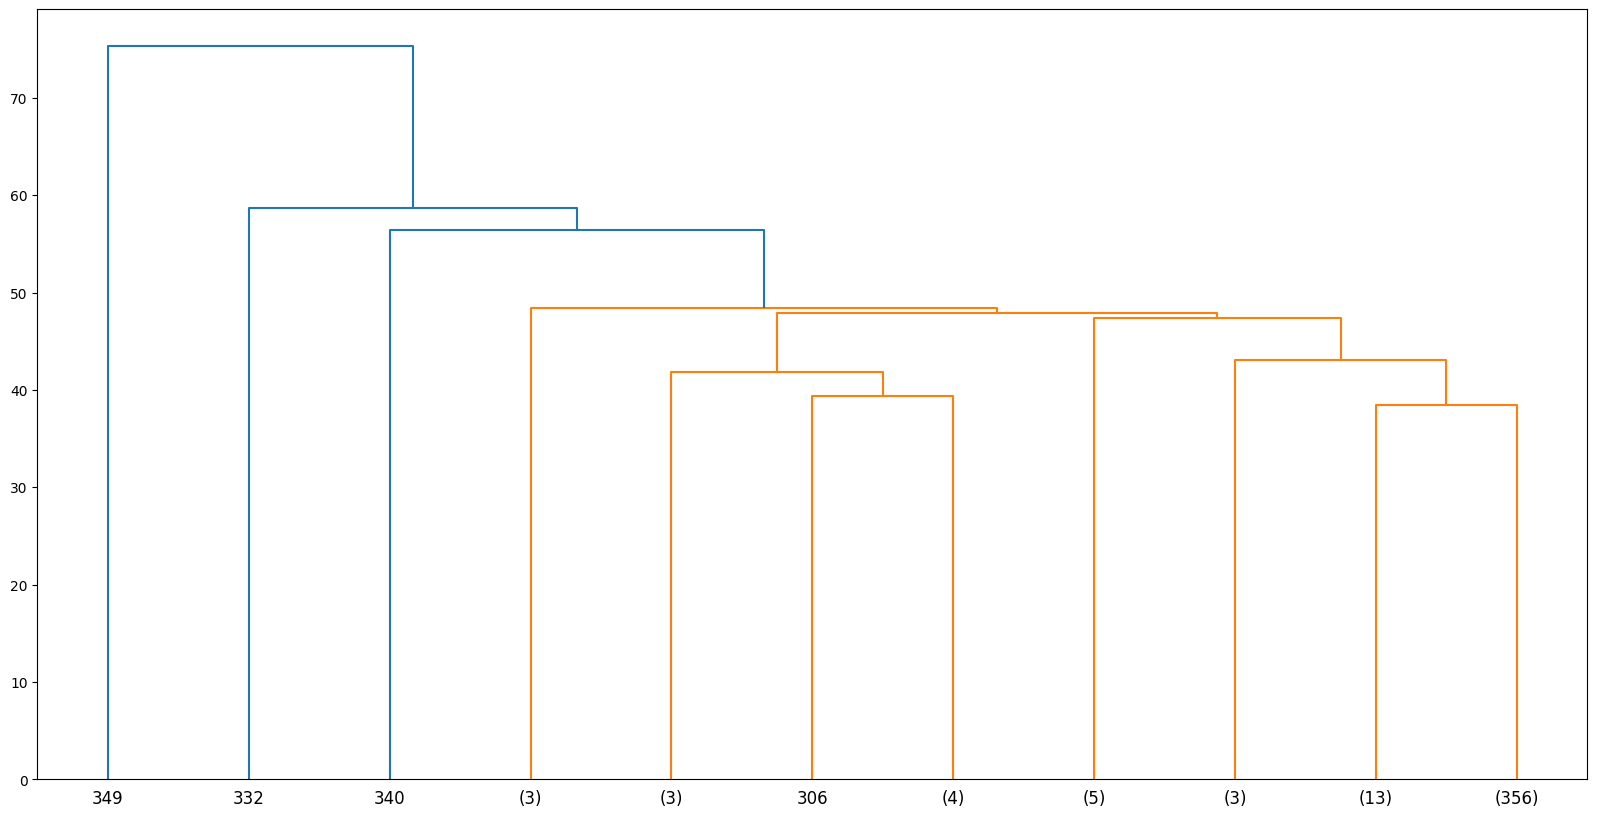

In [ ]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='lastp',p=11)